# 💰 Personal Expense Analytics
## CODTECH IT Solutions — Data Analytics Internship | Task 1

**Objective:** Analyze personal expense data to uncover spending patterns, category-wise breakdowns, monthly trends, and actionable insights using Python data analysis libraries.


In [2]:
# ── 1. Import Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 14, 'axes.labelsize': 12})

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [3]:
# ── 2. Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('personal_expenses.csv', parse_dates=['Date'])

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (144, 6)

First 5 rows:


,Date,Category,Description,Amount,Payment_Mode,Month
0,2024-01-02,Food,Grocery Shopping,850,UPI,January
1,2024-01-05,Transport,Auto Rickshaw,120,Cash,January
2,2024-01-07,Entertainment,Netflix Subscription,199,Credit Card,January
3,2024-01-10,Food,Restaurant Dinner,640,UPI,January
4,2024-01-12,Healthcare,Medicine,310,Cash,January


In [4]:
# ── 3. Exploratory Data Analysis ─────────────────────────────────────────────
print("=== Dataset Info ===")
df.info()
print("\n=== Statistical Summary ===")
df[['Amount']].describe().round(2)


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          144 non-null    datetime64[us]
 1   Category      144 non-null    str           
 2   Description   144 non-null    str           
 3   Amount        144 non-null    int64         
 4   Payment_Mode  144 non-null    str           
 5   Month         144 non-null    str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 11.5 KB

=== Statistical Summary ===


,Amount
count,144.00
mean,715.26
std,624.83
min,119.00
25%,299.00
50%,600.00
75%,900.00
max,4200.00


In [5]:
# ── 4. Data Quality Check ────────────────────────────────────────────────────
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nUnique Categories:", df['Category'].unique())
print("\nPayment Modes:", df['Payment_Mode'].unique())


Missing Values:
Date            0
Category        0
Description     0
Amount          0
Payment_Mode    0
Month           0
dtype: int64

Duplicate Rows: 0

Unique Categories: <ArrowStringArray>
[         'Food',     'Transport', 'Entertainment',    'Healthcare',
     'Education',     'Utilities', 'Personal Care',      'Shopping']
Length: 8, dtype: str

Payment Modes: <ArrowStringArray>
['UPI', 'Cash', 'Credit Card', 'Net Banking']
Length: 4, dtype: str


In [6]:
# ── 5. Feature Engineering ───────────────────────────────────────────────────
df['Month_Num'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter.map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})

# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

print("Feature engineering complete ✅")
df[['Date','Category','Amount','Month_Name','Quarter']].head(8)


Feature engineering complete ✅


,Date,Category,Amount,Month_Name,Quarter
0,2024-01-02,Food,850,January,Q1
1,2024-01-05,Transport,120,January,Q1
2,2024-01-07,Entertainment,199,January,Q1
3,2024-01-10,Food,640,January,Q1
4,2024-01-12,Healthcare,310,January,Q1
5,2024-01-15,Education,1499,January,Q1
6,2024-01-18,Food,920,January,Q1
7,2024-01-20,Utilities,780,January,Q1


In [7]:
# ── 6. Overall Spending Summary ──────────────────────────────────────────────
total = df['Amount'].sum()
avg_txn = df['Amount'].mean()
max_txn = df['Amount'].max()
min_txn = df['Amount'].min()
num_txn = len(df)

print(f"{'='*45}")
print(f"  📊  PERSONAL EXPENSE SUMMARY (2024)")
print(f"{'='*45}")
print(f"  Total Expenditure  : ₹{total:,.0f}")
print(f"  Total Transactions : {num_txn}")
print(f"  Avg. Transaction   : ₹{avg_txn:,.2f}")
print(f"  Highest Expense    : ₹{max_txn:,.0f}")
print(f"  Lowest Expense     : ₹{min_txn:,.0f}")
print(f"{'='*45}")


  📊  PERSONAL EXPENSE SUMMARY (2024)
  Total Expenditure  : ₹102,998
  Total Transactions : 144
  Avg. Transaction   : ₹715.26
  Highest Expense    : ₹4,200
  Lowest Expense     : ₹119


In [8]:
# ── 7. Category-Wise Spending Analysis ───────────────────────────────────────
cat_spend = df.groupby('Category')['Amount'].agg(['sum','mean','count']).round(2)
cat_spend.columns = ['Total_Spent', 'Avg_Per_Txn', 'Transactions']
cat_spend = cat_spend.sort_values('Total_Spent', ascending=False)
cat_spend['% Share'] = (cat_spend['Total_Spent'] / cat_spend['Total_Spent'].sum() * 100).round(2)

print("Category-wise Breakdown:")
cat_spend


Category-wise Breakdown:


,Total_Spent,Avg_Per_Txn,Transactions,% Share
Category,,,,
Food,32140,669.58,48,31.20
Shopping,24500,2227.27,11,23.79
Education,11326,943.83,12,11.00
Utilities,9364,780.33,12,9.09
Transport,8870,369.58,24,8.61
Entertainment,7488,394.11,19,7.27
Healthcare,6760,563.33,12,6.56
Personal Care,2550,425.00,6,2.48


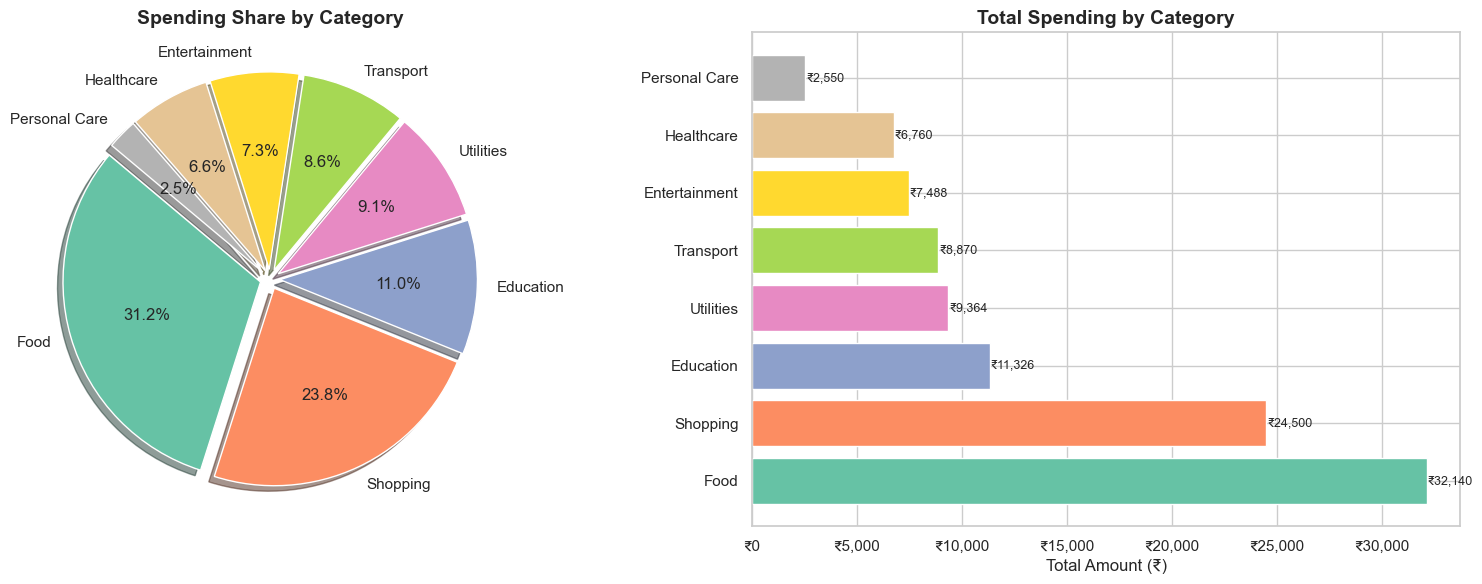

Chart saved ✅


In [9]:
# ── 8. Category Spending — Pie & Bar Charts ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
explode = [0.05] * len(cat_spend)
axes[0].pie(cat_spend['Total_Spent'], labels=cat_spend.index, autopct='%1.1f%%',
            startangle=140, explode=explode, shadow=True)
axes[0].set_title('Spending Share by Category', fontsize=14, fontweight='bold')

# Bar chart
colors = sns.color_palette('Set2', len(cat_spend))
bars = axes[1].barh(cat_spend.index, cat_spend['Total_Spent'], color=colors)
axes[1].set_xlabel('Total Amount (₹)')
axes[1].set_title('Total Spending by Category', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

for bar, val in zip(bars, cat_spend['Total_Spent']):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'₹{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('category_spending.png', bbox_inches='tight')
plt.show()
print("Chart saved ✅")


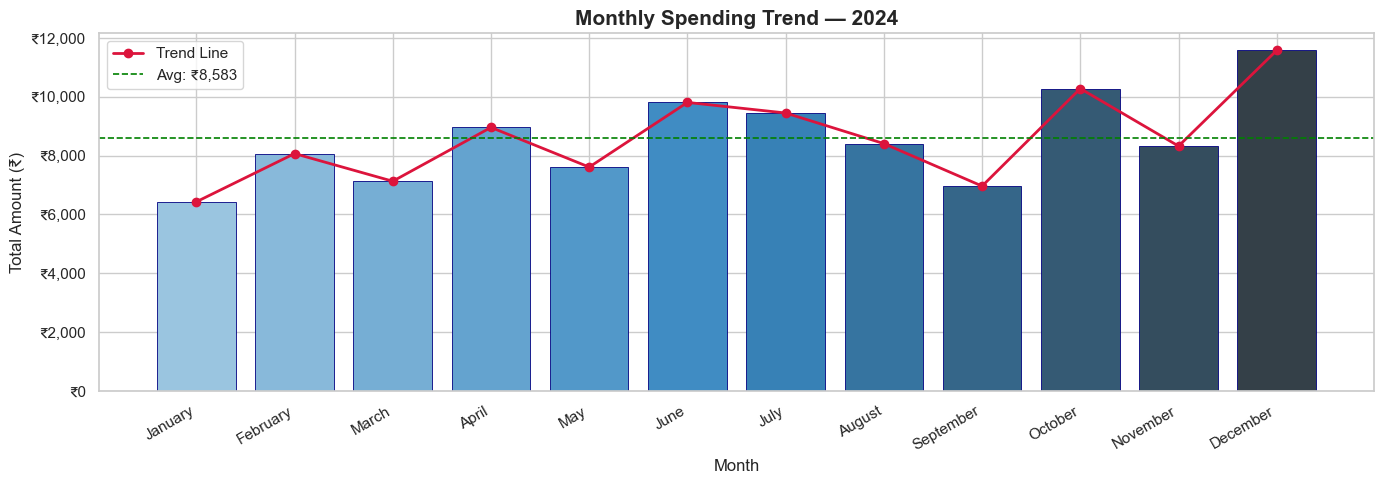

Highest Spending Month : December (₹11,578)
Lowest Spending Month  : January (₹6,428)


In [10]:
# ── 9. Monthly Spending Trend ────────────────────────────────────────────────
monthly = df.groupby('Month_Name')['Amount'].sum().reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.index, monthly.values, color=sns.color_palette('Blues_d', 12), edgecolor='navy', linewidth=0.6)
ax.plot(monthly.index, monthly.values, color='crimson', marker='o', linewidth=2, label='Trend Line')
ax.set_title('Monthly Spending Trend — 2024', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Amount (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=30, ha='right')
ax.legend()
ax.axhline(monthly.mean(), color='green', linestyle='--', linewidth=1.2, label=f'Avg: ₹{monthly.mean():,.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

print(f"Highest Spending Month : {monthly.idxmax()} (₹{monthly.max():,.0f})")
print(f"Lowest Spending Month  : {monthly.idxmin()} (₹{monthly.min():,.0f})")


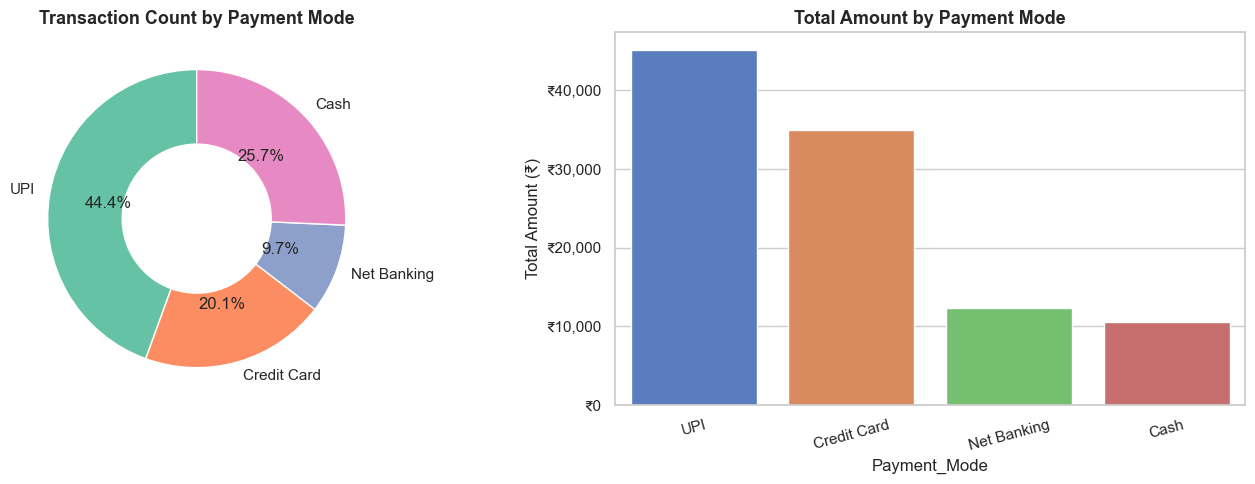

              Total_Amount  Transactions  % Usage
Payment_Mode                                     
UPI                  45140            64     44.4
Credit Card          34944            29     20.1
Net Banking          12364            14      9.7
Cash                 10550            37     25.7


In [11]:
# ── 10. Payment Mode Analysis ────────────────────────────────────────────────
pay_mode = df.groupby('Payment_Mode')['Amount'].agg(['sum','count']).round(2)
pay_mode.columns = ['Total_Amount','Transactions']
pay_mode['% Usage'] = (pay_mode['Transactions'] / pay_mode['Transactions'].sum() * 100).round(1)
pay_mode = pay_mode.sort_values('Total_Amount', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    pay_mode['Transactions'], labels=pay_mode.index, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.5))
axes[0].set_title('Transaction Count by Payment Mode', fontsize=13, fontweight='bold')

# Bar
sns.barplot(x=pay_mode.index, y=pay_mode['Total_Amount'], ax=axes[1],
            palette='muted', order=pay_mode.index)
axes[1].set_title('Total Amount by Payment Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('payment_mode.png', bbox_inches='tight')
plt.show()

print(pay_mode)


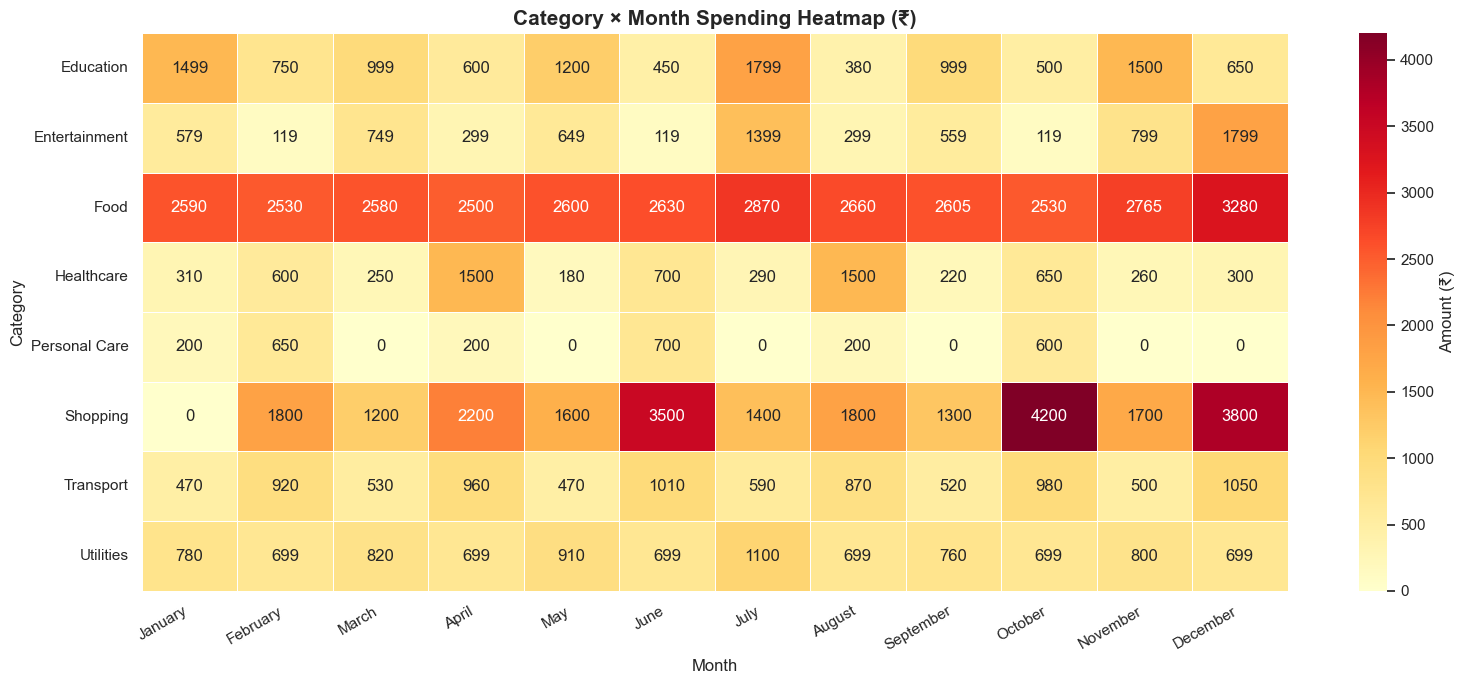

Heatmap saved ✅


In [12]:
# ── 11. Category × Month Heatmap ─────────────────────────────────────────────
pivot = df.pivot_table(index='Category', columns='Month_Name', values='Amount',
                       aggfunc='sum', fill_value=0)
pivot = pivot.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Amount (₹)'})
ax.set_title('Category × Month Spending Heatmap (₹)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()
print("Heatmap saved ✅")


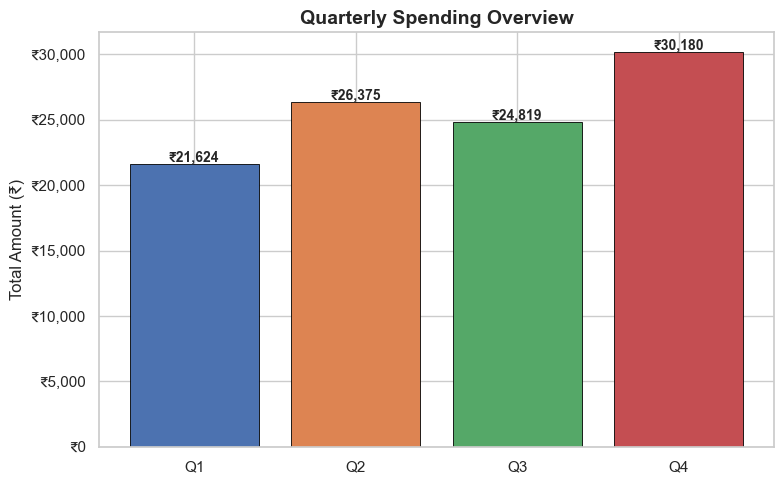

Quarter  Total_Spent
     Q1        21624
     Q2        26375
     Q3        24819
     Q4        30180


In [13]:
# ── 12. Quarterly Spending Breakdown ─────────────────────────────────────────
quarterly = df.groupby('Quarter')['Amount'].sum().reset_index()
quarterly.columns = ['Quarter', 'Total_Spent']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly['Quarter'], quarterly['Total_Spent'],
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='black', linewidth=0.6)
ax.set_title('Quarterly Spending Overview', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Amount (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

for bar, val in zip(bars, quarterly['Total_Spent']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'₹{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('quarterly.png', bbox_inches='tight')
plt.show()
print(quarterly.to_string(index=False))


In [14]:
# ── 13. Top 10 Highest Transactions ──────────────────────────────────────────
top10 = df.nlargest(10, 'Amount')[['Date','Category','Description','Amount','Payment_Mode']]
top10 = top10.reset_index(drop=True)
top10.index += 1
print("Top 10 Highest Expenses:")
top10


Top 10 Highest Expenses:


,Date,Category,Description,Amount,Payment_Mode
1,2024-10-24,Shopping,Festival Shopping,4200,Credit Card
2,2024-12-25,Shopping,Year-End Gifts,3800,Credit Card
3,2024-06-22,Shopping,Gadget,3500,Credit Card
4,2024-04-24,Shopping,Home Decor,2200,Credit Card
5,2024-02-25,Shopping,Clothing,1800,Credit Card
6,2024-08-23,Shopping,Home Essentials,1800,Credit Card
7,2024-07-13,Education,Online Course,1799,Credit Card
8,2024-11-27,Shopping,Clothing,1700,Credit Card
9,2024-05-27,Shopping,Clothing,1600,Credit Card
10,2024-04-10,Healthcare,Gym Membership,1500,Net Banking


In [15]:
# ── 14. Key Insights & Summary ───────────────────────────────────────────────
top_cat = cat_spend['Total_Spent'].idxmax()
top_cat_amt = cat_spend['Total_Spent'].max()
top_month = monthly.idxmax()
top_month_amt = monthly.max()
upi_pct = pay_mode.loc['UPI','% Usage']

print("=" * 55)
print("           📌  KEY INSIGHTS — 2024")
print("=" * 55)
print(f" 1. Total Annual Spend     : ₹{total:,.0f}")
print(f" 2. Top Spending Category  : {top_cat} (₹{top_cat_amt:,.0f})")
print(f" 3. Highest Spending Month : {top_month} (₹{top_month_amt:,.0f})")
print(f" 4. Most Used Payment Mode : UPI ({upi_pct}% of transactions)")
print(f" 5. Avg. Monthly Spend     : ₹{monthly.mean():,.0f}")
print(f" 6. Avg. Transaction Value : ₹{avg_txn:,.2f}")
print("=" * 55)
print()
print("💡 Recommendations:")
print("  • Food is the largest recurring expense — meal prepping can reduce costs.")
print("  • October (festival season) and December (year-end) are high-spend months.")
print("  • UPI dominates as a payment method — aligns with digital India adoption.")
print("  • Shopping spikes during festivals; a dedicated savings budget would help.")


           📌  KEY INSIGHTS — 2024
 1. Total Annual Spend     : ₹102,998
 2. Top Spending Category  : Food (₹32,140)
 3. Highest Spending Month : December (₹11,578)
 4. Most Used Payment Mode : UPI (44.4% of transactions)
 5. Avg. Monthly Spend     : ₹8,583
 6. Avg. Transaction Value : ₹715.26

💡 Recommendations:
  • Food is the largest recurring expense — meal prepping can reduce costs.
  • October (festival season) and December (year-end) are high-spend months.
  • UPI dominates as a payment method — aligns with digital India adoption.
  • Shopping spikes during festivals; a dedicated savings budget would help.
